# 1. IMPORT

In [1]:
import os
import gc
import random
import warnings
import numpy as np
import cv2
import h5py
from skimage.feature import local_binary_pattern
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import IncrementalPCA, PCA
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

print("Library versions:")
print(f"- NumPy: {np.__version__}")
print(f"- OpenCV: {cv2.__version__}")
print(f"- h5py: {h5py.__version__}")

Library versions:
- NumPy: 2.0.2
- OpenCV: 4.13.0
- h5py: 3.15.1


# 2. CONFIG

In [2]:

import os

CONFIG = {
    "BASE_PATH": "/kaggle/input/datasets/shivamardeshna/real-and-fake-images-dataset-for-image-forensics/Data Set 1/Data Set 1",
    "WORKING_DIR": "/kaggle/working",
    
    "IMG_SIZE": (256, 256),   
    "BATCH_SIZE": 512, 
    "SEED": 42,             
    
    "ELA_QUALITY": 90,
    "FFT_LOW_RADIUS": 30,
    "FFT_MID_RADIUS": 85,
    "LBP_RADIUS": 1,
    "LBP_POINTS": 8,
    "LBP_METHOD": "uniform",
}

CONFIG["TRAIN_DIR"] = os.path.join(CONFIG["BASE_PATH"], "train")
CONFIG["VALID_DIR"] = os.path.join(CONFIG["BASE_PATH"], "validation")
CONFIG["TEST_DIR"] = os.path.join(CONFIG["BASE_PATH"], "test")

CONFIG["H5_TRAIN"] = os.path.join(CONFIG["WORKING_DIR"], "train_features.h5")
CONFIG["H5_VALID"] = os.path.join(CONFIG["WORKING_DIR"], "valid_features.h5")
CONFIG["H5_TEST"] = os.path.join(CONFIG["WORKING_DIR"], "test_features.h5")

print("Configuration:")
print(f"- Batch Size: {CONFIG['BATCH_SIZE']}")
print(f"- Feature Seed: {CONFIG['SEED']}")


Configuration:
- Batch Size: 512
- Feature Seed: 42


# 3. DATA - FEATURE ENGINEERING

## 3.1. Initialization Worker Process

In [3]:
def _init_worker(cfg_h, cfg_w, low_r, mid_r, ela_q, lbp_p, lbp_r, lbp_m):
    global W_H, W_W, W_FFT_MASKS, W_ELA_QUALITY, W_LBP_POINTS, W_LBP_RADIUS, W_LBP_METHOD
    
    W_H, W_W = cfg_h, cfg_w
    W_ELA_QUALITY = ela_q
    W_LBP_POINTS = lbp_p
    W_LBP_RADIUS = lbp_r
    W_LBP_METHOD = lbp_m
    
    CY, CX = W_H // 2, W_W // 2
    Y, X = np.ogrid[:W_H, :W_W]
    DIST = np.sqrt((X - CX)**2 + (Y - CY)**2)
    
    W_FFT_MASKS = [
        DIST <= low_r,
        (DIST > low_r) & (DIST <= mid_r),
        DIST > mid_r
    ]

print("SET UP OK")

SET UP OK


## 3.2. Extraction Function

In [4]:
def extract_single_image_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
        
    # Ảnh gốc 256x256 dùng cho Forensic Features (ELA, FFT, LBP)
    img = cv2.resize(img, (W_W, W_H))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Raw Pixel Flatten - RESIZED 128X128
    img_raw_small = cv2.resize(img_rgb, (128, 128))
    raw_features = (img_raw_small / 255.0).flatten()
    
    # ELA Features
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), W_ELA_QUALITY]
    _, encoded_img = cv2.imencode('.jpg', img, encode_param)
    recompressed = cv2.imdecode(encoded_img, 1)
    recompressed_rgb = cv2.cvtColor(recompressed, cv2.COLOR_BGR2RGB)
    
    diff = np.abs(img_rgb.astype(np.int16) - recompressed_rgb.astype(np.int16))
    ela_features = np.concatenate([np.mean(diff, axis=(0,1)), np.max(diff, axis=(0,1)), np.std(diff, axis=(0,1))])
    
    # FFT Features
    f_transform = np.fft.fft2(img_gray)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = np.log(1 + np.abs(f_shift))
    
    fft_features = []
    for mask in W_FFT_MASKS:
        band_vals = magnitude_spectrum[mask]
        fft_features.extend([np.mean(band_vals), np.std(band_vals), np.max(band_vals)])
    fft_features = np.array(fft_features)
    
    # LBP Features
    lbp = local_binary_pattern(img_gray, P=W_LBP_POINTS, R=W_LBP_RADIUS, method=W_LBP_METHOD)
    num_bins = W_LBP_POINTS + 2
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=num_bins, range=(0, num_bins), density=True)

    # YCbCr Color Space Features (Kênh Cr và Cb)
    img_ycbcr = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    cr_hist, _ = np.histogram(img_ycbcr[:,:,1].ravel(), bins=32, range=(0, 256), density=True)
    cb_hist, _ = np.histogram(img_ycbcr[:,:,2].ravel(), bins=32, range=(0, 256), density=True)
    color_features = np.concatenate([cr_hist, cb_hist])
    
    # Feature Fusion
    return np.concatenate([raw_features, ela_features, fft_features, lbp_hist, color_features]).astype(np.float32)

print("Feature Engineering OK")

Feature Engineering OK


## 3.3. Load Data

In [5]:
def get_filepaths_and_labels(directory):
    data = []
    if not os.path.exists(directory): return data
    for class_name in os.listdir(directory):
        class_dir = os.path.join(directory, class_name)
        if not os.path.isdir(class_dir): continue
        label = 0 if class_name.lower() == 'real' else 1
        for f in os.listdir(class_dir):
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                data.append((os.path.join(class_dir, f), label))
    random.seed(CONFIG.get("SEED", 42))
    random.shuffle(data)
    return data

print("DATA OK")

DATA OK


## 3.4. Save HDF5 & Extraction

In [6]:
def process_and_save_hdf5(directory, h5_path, desc, expected_dim=None):
    data = get_filepaths_and_labels(directory)
    total_samples = len(data)
    if total_samples == 0: return expected_dim
        
    if expected_dim is None:
        _init_worker(*CONFIG["IMG_SIZE"], CONFIG["FFT_LOW_RADIUS"], CONFIG["FFT_MID_RADIUS"], 
                     CONFIG["ELA_QUALITY"], CONFIG["LBP_POINTS"], CONFIG["LBP_RADIUS"], CONFIG["LBP_METHOD"])
        for path, _ in data:
            sample_feat = extract_single_image_features(path)
            if sample_feat is not None:
                expected_dim = sample_feat.shape[0]
                CONFIG["DIM_TOTAL"] = expected_dim
                print(f"Calculated DIM_TOTAL = {expected_dim} features per image...")
                break
        if expected_dim is None: raise ValueError(f"All images in {directory} are corrupted!")
            
    print(f"Initializing HDF5: {h5_path}")
    
    with h5py.File(h5_path, 'w') as f:
        X_dataset = f.create_dataset('X', shape=(total_samples, expected_dim), 
                                     maxshape=(total_samples, expected_dim), 
                                     dtype=np.float32, chunks=True, fillvalue=np.nan)
        y_dataset = f.create_dataset('y', shape=(total_samples,), 
                                     maxshape=(total_samples,), 
                                     dtype=np.int8)
        
        valid_idx = 0
        workers = max(1, os.cpu_count() - 1)
        
        with ProcessPoolExecutor(max_workers=workers, 
                                 initializer=_init_worker, 
                                 initargs=(*CONFIG["IMG_SIZE"], CONFIG["FFT_LOW_RADIUS"], CONFIG["FFT_MID_RADIUS"],
                                           CONFIG["ELA_QUALITY"], CONFIG["LBP_POINTS"], CONFIG["LBP_RADIUS"], CONFIG["LBP_METHOD"])) as executor:
            
            with tqdm(total=total_samples, desc=desc, unit="img") as pbar:
                for i in range(0, total_samples, CONFIG["BATCH_SIZE"]):
                    batch_data = data[i:i + CONFIG["BATCH_SIZE"]]
                    futures = {executor.submit(extract_single_image_features, p): l for p, l in batch_data}
                    
                    X_batch, y_batch = [], []
                    
                    for future in as_completed(futures):
                        try:
                            feat = future.result()
                        except Exception as e:
                            print(f"\n[ERROR] Worker exception: {e}")
                            feat = None
                            
                        label = futures[future]
                        
                        if feat is not None:
                            X_batch.append(feat)
                            y_batch.append(label)
                            
                        pbar.update(1)
                            
                    if X_batch:
                        chunk_size = len(X_batch)
                        X_dataset[valid_idx : valid_idx + chunk_size] = np.array(X_batch)
                        y_dataset[valid_idx : valid_idx + chunk_size] = np.array(y_batch)
                        valid_idx += chunk_size
                        
                    del X_batch, y_batch, futures
                    gc.collect()
                
        if valid_idx < total_samples:
            X_dataset.resize((valid_idx, expected_dim))
            y_dataset.resize((valid_idx,))
            print(f"-> Dropped {total_samples - valid_idx} corrupted images. Final count: {valid_idx}")

    return expected_dim

In [7]:
calculated_dim = process_and_save_hdf5(CONFIG["TRAIN_DIR"], CONFIG["H5_TRAIN"], "Extracting TRAIN", expected_dim=None)
process_and_save_hdf5(CONFIG["VALID_DIR"], CONFIG["H5_VALID"], "Extracting VALID", expected_dim=calculated_dim)
process_and_save_hdf5(CONFIG["TEST_DIR"], CONFIG["H5_TEST"], "Extracting TEST", expected_dim=calculated_dim)


print("--- DATASET SHAPES ---")

try:
    with h5py.File(CONFIG["H5_TRAIN"], 'r') as f:
        print(f"TRAIN set : X shape = {f['X'].shape} | y shape = {f['y'].shape}")
        
    with h5py.File(CONFIG["H5_VALID"], 'r') as f:
        print(f"VALID set : X shape = {f['X'].shape} | y shape = {f['y'].shape}")
        
    with h5py.File(CONFIG["H5_TEST"], 'r') as f:
        print(f"TEST set  : X shape = {f['X'].shape}  | y shape = {f['y'].shape}")
        
    print("-" * 40)
    print(f"Features per image: {CONFIG['DIM_TOTAL']}")

except Exception as e:
    print(f"[ERROR] Failed to read HDF5 files: {e}")

Calculated DIM_TOTAL = 49244 features per image...
Initializing HDF5: /kaggle/working/train_features.h5


Extracting TRAIN:   0%|          | 0/40002 [00:00<?, ?img/s]

Initializing HDF5: /kaggle/working/valid_features.h5


Extracting VALID:   0%|          | 0/12360 [00:00<?, ?img/s]

Initializing HDF5: /kaggle/working/test_features.h5


Extracting TEST:   0%|          | 0/5227 [00:00<?, ?img/s]

--- DATASET SHAPES ---
TRAIN set : X shape = (40002, 49244) | y shape = (40002,)
VALID set : X shape = (12360, 49244) | y shape = (12360,)
TEST set  : X shape = (5227, 49244)  | y shape = (5227,)
----------------------------------------
Features per image: 49244


# 4. Scaler - PCA (99% Variance)

## 4.1. Estimating Optimal Components

In [8]:
print("--- Estimating Optimal Components for 99% Variance (Random 5000 Images) ---")
with h5py.File(CONFIG["H5_TRAIN"], 'r') as f_train:
    sample_size = min(5000, f_train['X'].shape[0])
    print(f"Loading {sample_size} random samples for estimation...")
    
    indices = np.random.choice(f_train['X'].shape[0], sample_size, replace=False)
    indices = np.sort(indices) 
    X_sample = f_train['X'][indices]
    
    scaler_temp = StandardScaler()
    X_sample_sc = scaler_temp.fit_transform(X_sample)
    
    pca_estimator = PCA(n_components=0.99)
    pca_estimator.fit(X_sample_sc)
    
    OPTIMAL_COMPONENTS = pca_estimator.n_components_
    print(f"Optimal Components: {OPTIMAL_COMPONENTS} for 99% Variance")
    
    del X_sample, X_sample_sc, scaler_temp, pca_estimator
    gc.collect()

--- Estimating Optimal Components for 99% Variance (Random 5000 Images) ---
Loading 5000 random samples for estimation...
Optimal Components: 2007 for 99% Variance


## 4.2. Scaler & PCA on Train

In [9]:
CHUNK_SIZE = 2500  

scaler = StandardScaler()
pca = IncrementalPCA(n_components=OPTIMAL_COMPONENTS, whiten=False)

print("--- Fitting StandardScaler on TRAIN set ---")
with h5py.File(CONFIG["H5_TRAIN"], 'r') as f_train:
    num_train = f_train['X'].shape[0]
    for i in tqdm(range(0, num_train, CHUNK_SIZE), desc="Fitting Scaler"):
        X_chunk = f_train['X'][i:i + CHUNK_SIZE]
        scaler.partial_fit(X_chunk)
        del X_chunk
        gc.collect()

print(f"\n--- PCA (Components={OPTIMAL_COMPONENTS}) on TRAIN set ---")
with h5py.File(CONFIG["H5_TRAIN"], 'r') as f_train:
    pca_batch = max(CHUNK_SIZE, OPTIMAL_COMPONENTS + 100)
    for i in tqdm(range(0, num_train, pca_batch), desc="Fitting PCA"):
        X_chunk = f_train['X'][i:i + pca_batch]
        if len(X_chunk) >= OPTIMAL_COMPONENTS:
            X_chunk_sc = scaler.transform(X_chunk)
            pca.partial_fit(X_chunk_sc)
            del X_chunk_sc
        del X_chunk
        gc.collect()

--- Fitting StandardScaler on TRAIN set ---


Fitting Scaler:   0%|          | 0/17 [00:00<?, ?it/s]


--- PCA (Components=2007) on TRAIN set ---


Fitting PCA:   0%|          | 0/17 [00:00<?, ?it/s]

# 4.3. Processing & Saving

In [10]:
CONFIG["H5_TRAIN_PCA"] = os.path.join(CONFIG["WORKING_DIR"], "train_pca.h5")
CONFIG["H5_VALID_PCA"] = os.path.join(CONFIG["WORKING_DIR"], "valid_pca.h5")
CONFIG["H5_TEST_PCA"] = os.path.join(CONFIG["WORKING_DIR"], "test_pca.h5")

def process_and_save_final(input_h5, output_h5, desc):
    with h5py.File(input_h5, 'r') as f_in, h5py.File(output_h5, 'w') as f_out:
        num_samples = f_in['X'].shape[0]
        
        X_pca = f_out.create_dataset('X_pca', shape=(num_samples, OPTIMAL_COMPONENTS), dtype=np.float32, chunks=True)
        y_out = f_out.create_dataset('y', shape=(num_samples,), dtype=np.int8)
        
        for i in tqdm(range(0, num_samples, CHUNK_SIZE), desc=desc):
            X_chunk = f_in['X'][i:i + CHUNK_SIZE]
            
            X_sc = scaler.transform(X_chunk)
            X_pca_chunk = pca.transform(X_sc)
            
            X_pca[i:i + CHUNK_SIZE] = X_pca_chunk
            y_out[i:i + CHUNK_SIZE] = f_in['y'][i:i + CHUNK_SIZE]
            
            del X_chunk, X_sc, X_pca_chunk
        gc.collect()
        print(f"Path: {os.path.basename(output_h5)} (Shape: {X_pca.shape})")

In [11]:
print("\n--- Transforming all datasets to final PCA space ---")
process_and_save_final(CONFIG["H5_TRAIN"], CONFIG["H5_TRAIN_PCA"], "Transforming TRAIN")
process_and_save_final(CONFIG["H5_VALID"], CONFIG["H5_VALID_PCA"], "Transforming VALID")
process_and_save_final(CONFIG["H5_TEST"], CONFIG["H5_TEST_PCA"], "Transforming TEST")


print("--- DATASET SHAPES (Post-PCA) ---")

try:
    with h5py.File(CONFIG["H5_TRAIN_PCA"], 'r') as f:
        train_shape = f['X_pca'].shape
        print(f"TRAIN set : X_pca shape = {train_shape} | y shape = {f['y'].shape}")
        
    with h5py.File(CONFIG["H5_VALID_PCA"], 'r') as f:
        print(f"VALID set : X_pca shape = {f['X_pca'].shape} | y shape = {f['y'].shape}")
        
    with h5py.File(CONFIG["H5_TEST_PCA"], 'r') as f:
        print(f"TEST set  : X_pca shape = {f['X_pca'].shape}  | y shape = {f['y'].shape}")
 
except Exception as e:
    print(f"[ERROR] Failed to read PCA HDF5 files: {e}")


--- Transforming all datasets to final PCA space ---


Transforming TRAIN:   0%|          | 0/17 [00:00<?, ?it/s]

Path: train_pca.h5 (Shape: (40002, 2007))


Transforming VALID:   0%|          | 0/5 [00:00<?, ?it/s]

Path: valid_pca.h5 (Shape: (12360, 2007))


Transforming TEST:   0%|          | 0/3 [00:00<?, ?it/s]

Path: test_pca.h5 (Shape: (5227, 2007))
--- DATASET SHAPES (Post-PCA) ---
TRAIN set : X_pca shape = (40002, 2007) | y shape = (40002,)
VALID set : X_pca shape = (12360, 2007) | y shape = (12360,)
TEST set  : X_pca shape = (5227, 2007)  | y shape = (5227,)


# 5. Gaussian Discriminant Analysis

## 5.1. Define Model

In [12]:
class GDA:
    def __init__(self, reg_param=0.0, store_covariance=True):
        self.reg_param = reg_param
        self.store_covariance = store_covariance

        self.phi = None
        self.mu0 = None
        self.mu1 = None
        self.sigma = None
        
        self.sigma_inv = None
        self.log_det_sigma = None

    def fit(self, X, y):
        m, n = X.shape
        self.phi = np.mean(y == 1)

        X0 = X[y == 0]
        X1 = X[y == 1]
        
        self.mu0 = np.mean(X0, axis=0)
        self.mu1 = np.mean(X1, axis=0)
        
        X_centered = np.copy(X)
        X_centered[y == 0] -= self.mu0
        X_centered[y == 1] -= self.mu1
        
        self.sigma = (X_centered.T @ X_centered) / m
        
        if self.reg_param > 0:
            self.sigma += self.reg_param * np.eye(n)
            
        self.sigma_inv = np.linalg.pinv(self.sigma)
        _, self.log_det_sigma = np.linalg.slogdet(self.sigma)

    def predict_proba(self, X):
        delta0 = X - self.mu0
        log_p_x_given_y0 = -0.5 * np.sum((delta0 @ self.sigma_inv) * delta0, axis=1) - 0.5 * self.log_det_sigma
        log_prob0 = log_p_x_given_y0 + np.log(1 - self.phi)
        
        delta1 = X - self.mu1
        log_p_x_given_y1 = -0.5 * np.sum((delta1 @ self.sigma_inv) * delta1, axis=1) - 0.5 * self.log_det_sigma
        log_prob1 = log_p_x_given_y1 + np.log(self.phi)
        
        # Softmax
        max_log_prob = np.maximum(log_prob0, log_prob1)
        prob0 = np.exp(log_prob0 - max_log_prob)
        prob1 = np.exp(log_prob1 - max_log_prob)
        
        sum_prob = prob0 + prob1
        return np.vstack([prob0 / sum_prob, prob1 / sum_prob]).T

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)
        
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

## 5.2. GridSearch on Valid dataset

In [13]:
with h5py.File(CONFIG["H5_TRAIN_PCA"], 'r') as f:
    X_train_pca = f['X_pca'][:]
    y_train = f['y'][:]

with h5py.File(CONFIG["H5_VALID_PCA"], 'r') as f:
    X_valid_pca = f['X_pca'][:]
    y_valid = f['y'][:]

print(f"Train: {X_train_pca.shape} | Valid: {X_valid_pca.shape}")
max_features_available = X_train_pca.shape[1]

Train: (40002, 2007) | Valid: (12360, 2007)


In [17]:
import json

k_candidates = [400, 500, 600, 650, 700, 710, 725, 750]
reg_params = [0.001, 0.01, 0.1, 0.3, 0.5]

results = []
best_acc = 0.0
best_params = {}
best_gda_model = None

print("\n--- GRID SEARCH GDA ---")

for k in k_candidates:
    if k > max_features_available:
        continue
        
    X_train_k = X_train_pca[:, :k]
    X_valid_k = X_valid_pca[:, :k]
    
    for reg in reg_params:
        gda = GDA(reg_param=reg, store_covariance=True)
        gda.fit(X_train_k, y_train)
        
        acc = gda.score(X_valid_k, y_valid)
        results.append({'k_components': k, 'reg_param': reg, 'val_accuracy': acc})
        
        print(f"Trained: k={k:4d} | reg={reg:5.3f} => Val Acc: {acc*100:.2f}%")
        
        if acc > best_acc:
            best_acc = acc
            best_params = {'k_components': k, 'reg_param': reg}
            best_gda_model = gda

print(f"\n BEST PARAMS: k = {best_params['k_components']}, reg = {best_params['reg_param']} (Acc: {best_acc*100:.2f}%)")

with open(os.path.join(CONFIG["WORKING_DIR"], 'gda_best_params.json'), 'w') as f:
    json.dump(best_params, f)



--- GRID SEARCH GDA ---
Trained: k= 400 | reg=0.001 => Val Acc: 75.85%
Trained: k= 400 | reg=0.010 => Val Acc: 75.83%
Trained: k= 400 | reg=0.100 => Val Acc: 75.84%
Trained: k= 400 | reg=0.300 => Val Acc: 75.86%
Trained: k= 400 | reg=0.500 => Val Acc: 75.87%
Trained: k= 500 | reg=0.001 => Val Acc: 76.13%
Trained: k= 500 | reg=0.010 => Val Acc: 76.14%
Trained: k= 500 | reg=0.100 => Val Acc: 76.13%
Trained: k= 500 | reg=0.300 => Val Acc: 76.17%
Trained: k= 500 | reg=0.500 => Val Acc: 76.11%
Trained: k= 600 | reg=0.001 => Val Acc: 76.61%
Trained: k= 600 | reg=0.010 => Val Acc: 76.62%
Trained: k= 600 | reg=0.100 => Val Acc: 76.67%
Trained: k= 600 | reg=0.300 => Val Acc: 76.69%
Trained: k= 600 | reg=0.500 => Val Acc: 76.68%
Trained: k= 650 | reg=0.001 => Val Acc: 77.00%
Trained: k= 650 | reg=0.010 => Val Acc: 77.00%
Trained: k= 650 | reg=0.100 => Val Acc: 76.95%
Trained: k= 650 | reg=0.300 => Val Acc: 76.85%
Trained: k= 650 | reg=0.500 => Val Acc: 76.88%
Trained: k= 700 | reg=0.001 => Val 

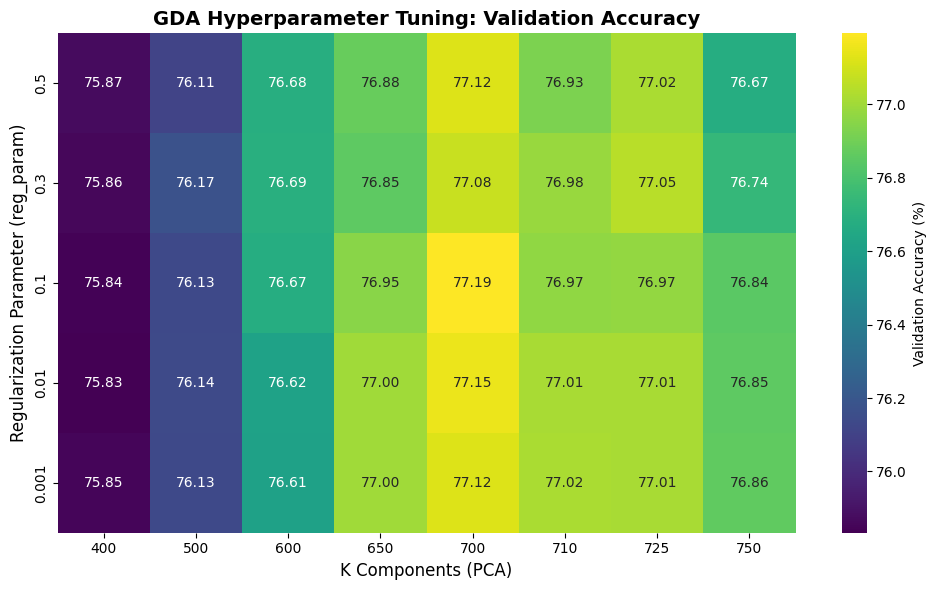

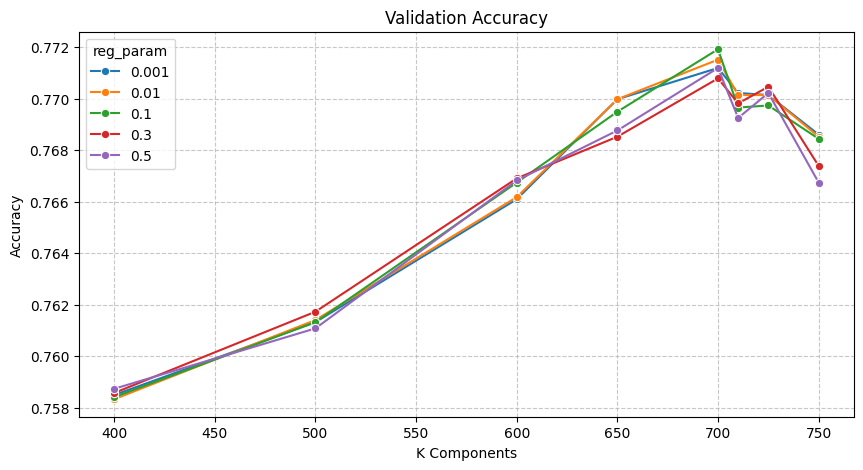

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_results = pd.DataFrame(results)

heatmap_data = df_results.pivot(index='reg_param', columns='k_components', values='val_accuracy')

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data * 100, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'Validation Accuracy (%)'})
plt.title("GDA Hyperparameter Tuning: Validation Accuracy", fontsize=14, fontweight='bold')
plt.xlabel("K Components (PCA)", fontsize=12)
plt.ylabel("Regularization Parameter (reg_param)", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_results, x='k_components', y='val_accuracy', hue='reg_param', marker='o', palette='tab10')
plt.title("Validation Accuracy")
plt.xlabel("K Components")
plt.ylabel("Accuracy")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="reg_param")
plt.show()

## 5.3. Train Model with Best Params on Train+Validation data

### 5.3.1. Final Model on Combine Data

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("[LOAD BEST PARAMETERS]")
with open(os.path.join(CONFIG["WORKING_DIR"], 'gda_best_params.json'), 'r') as f:
    best_params = json.load(f)

best_k = best_params['k_components']
best_reg = best_params['reg_param']
print(f"-> Best K Components: {best_k}")
print(f"-> Best Regularization: {best_reg}")

print("\n--- COMBINE DATA (TRAIN + VALID) ---")

with h5py.File(CONFIG["H5_TRAIN_PCA"], 'r') as f:
    X_train = f['X_pca'][:, :best_k]
    y_train = f['y'][:]

with h5py.File(CONFIG["H5_VALID_PCA"], 'r') as f:
    X_valid = f['X_pca'][:, :best_k]
    y_valid = f['y'][:]

with h5py.File(CONFIG["H5_TEST_PCA"], 'r') as f:
    X_test = f['X_pca'][:, :best_k]
    y_test = f['y'][:]

X_train_full = np.vstack((X_train, X_valid))
y_train_full = np.concatenate((y_train, y_valid))

print("\nAfter Combine Train & Validation:")
print(f"-> Training Data Shape: {X_train_full.shape}")
print(f"-> Test Data Shape: {X_test.shape}")


print("\n--- RETRAINING FINAL GDA MODEL ---")
final_gda = GDA(reg_param=best_reg, store_covariance=True)
final_gda.fit(X_train_full, y_train_full)

print ("Train Model OK")

[LOAD BEST PARAMETERS]
-> Best K Components: 700
-> Best Regularization: 0.1

--- COMBINE DATA (TRAIN + VALID) ---

After Combine Train & Validation:
-> Training Data Shape: (52362, 700)
-> Test Data Shape: (5227, 700)

--- RETRAINING FINAL GDA MODEL ---
Train Model OK


### 5.3.2. Evaluation on Test

[EVALUATION ON TEST SET]
   - FINAL ACCURACY : 71.19%
   - F1-SCORE (FAKE): 0.7543
   - ROC-AUC SCORE  : 0.8055

------------------------------------------------------------
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    REAL (0)       0.82      0.54      0.65      2604
    FAKE (1)       0.66      0.88      0.75      2623

    accuracy                           0.71      5227
   macro avg       0.74      0.71      0.70      5227
weighted avg       0.74      0.71      0.70      5227



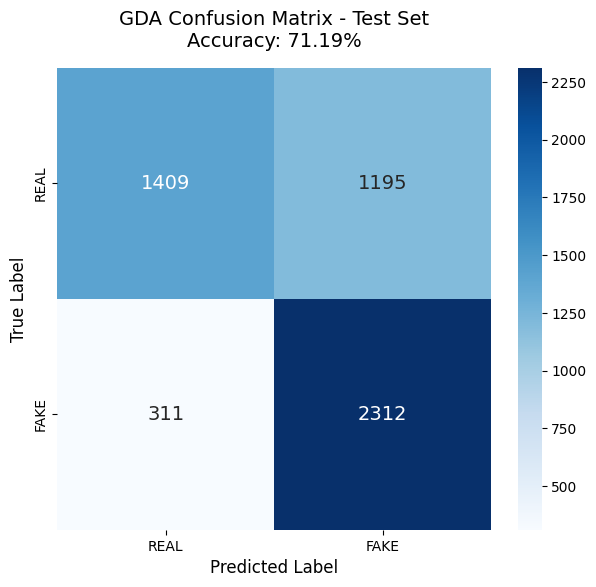

In [29]:
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score, roc_auc_score, roc_curve)

print("[EVALUATION ON TEST SET]")
print("=" * 60)
y_pred = final_gda.predict(X_test)
y_prob = final_gda.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"   - FINAL ACCURACY : {acc * 100:.2f}%")
print(f"   - F1-SCORE (FAKE): {f1:.4f}")
print(f"   - ROC-AUC SCORE  : {roc_auc:.4f}\n")

print("-" * 60)
print("CLASSIFICATION REPORT:")
target_names = ['REAL (0)', 'FAKE (1)']
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['REAL', 'FAKE'], 
            yticklabels=['REAL', 'FAKE'],
            annot_kws={"size": 14})
plt.title(f"GDA Confusion Matrix - Test Set\nAccuracy: {acc*100:.2f}%", fontsize=14, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

# REPORT - EVALUATION

**1. Overall Performance**
* **Accuracy: 71.19%** - Mức điểm trung bình khá. Trong bối cảnh bài toán phân biệt ảnh thật/giả với các đặc trưng kỹ thuật số phức tạp, con số này cho thấy mô hình đã học được các ranh giới phân loại nhất định, nhưng vẫn gặp khó khăn ở vùng dữ liệu giao thoa.
* **ROC-AUC Score: 0.8055** - ROC-AUC > 0.8 chứng tỏ khả năng phân táchgiữa cụm REAL và FAKE của thuật toán GDA là tốt. Ma trận hiệp phương sai đã làm tốt việc phân bố xác suất, mở ra cơ hội tăng điểm số bằng Threshold Tuning.

---

**2. Confusion Matrix**
Dữ liệu tập Test rất cân bằng (2604 REAL vs 2623 FAKE). Tuy nhiên, cách GDA dự đoán lại có sự "thiên vị" rõ rệt:
* **True Positive (Đoán đúng FAKE): 2312 ảnh**
* **False Negative (Bỏ lọt FAKE): 311 ảnh** - Mô hình hiếm khi bị lọt ảnh FAKE.
* **True Negative (Đoán đúng REAL): 1409 ảnh** - Chỉ hơn 50% ảnh thật.
* **False Positive (Nhận nhầm REAL thành FAKE): 1195 ảnh** - Mô hình đang quá "nhạy cảm", sẵn sàng gán nhãn FAKE cho các bức ảnh REAL chỉ vì chúng có chút nhiễu hoặc sai lệch màu sắc.

---

**3. Classification Report**
* **Đánh giá trên Lớp FAKE (1) - Lớp mục tiêu:**
    * **Recall (0.88):** Recall cao cho lớp mục tiêu là một điểm tốt.
    * **Precision (0.66):** Điểm yếu đi kèm của Recall cao. Vì mô hình phán FAKE quá rộng (bắt nhầm cả ngàn ảnh thật), độ tin cậy của mỗi cảnh báo FAKE bị kéo rớt xuống còn 66%.

* **Đánh giá trên Lớp REAL (0):**
    * **Precision (0.82):** Rất tốt. Khi mô hình đã đoán là ảnh REAL thì xác suất đúng lên tới 82%.
    * **Recall (0.54):** Rất thấp. Gần một nửa số ảnh thật bị mô hình đoán là FAKE.

---

**TỔNG KẾT**

GDA đang đánh giá với tiêu chí: Quyết không bỏ lọt 1 ảnh giả.
* **Ứng dụng thực tế:** Phù hợp cho các hệ thống an ninh cấp cao (như xác thực căn cước công dân), nơi việc để lọt ảnh giả sẽ gây hậu quả nghiêm trọng hơn việc bắt người dùng chụp lại ảnh thật.
* **Cách khắc phục:** Do ROC-AUC đang rất tốt (0.80), ta hoàn toàn có thể áp dụng kỹ thuật **Threshold Tuning** (Tinh chỉnh ngưỡng xác suất). Bằng cách nâng ngưỡng quyết định từ `0.5` lên `0.6` hoặc `0.65`, mô hình sẽ bớt khắt khe lại, giúp cứu được hàng ngàn ảnh REAL (Giảm False Positive) và cân bằng lại Accuracy mà không làm rơi rụng quá nhiều ảnh FAKE.

# 6.Logistic Regression

## 6.1 Import libraries

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score
)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import joblib

## 6.2 Load data

In [4]:
import os
import h5py
import numpy as np

DATA_DIR = "/kaggle/input/datasets/trtai0111/real-and-fake-image"   # đổi đúng tên folder dataset của bạn nếu khác

TRAIN_PCA_PATH = os.path.join(DATA_DIR, "train_pca.h5")
VALID_PCA_PATH = os.path.join(DATA_DIR, "valid_pca.h5")
TEST_PCA_PATH  = os.path.join(DATA_DIR, "test_pca.h5")


def inspect_h5(path):
    print(f"\nFile: {path}")
    with h5py.File(path, "r") as f:
        print("Keys:", list(f.keys()))
        for key in f.keys():
            print(f"  {key}: shape={f[key].shape}, dtype={f[key].dtype}")


inspect_h5(TRAIN_PCA_PATH)
inspect_h5(VALID_PCA_PATH)
inspect_h5(TEST_PCA_PATH)


File: /kaggle/input/datasets/trtai0111/real-and-fake-image/train_pca.h5
Keys: ['X_pca', 'y']
  X_pca: shape=(40002, 2009), dtype=float32
  y: shape=(40002,), dtype=int8

File: /kaggle/input/datasets/trtai0111/real-and-fake-image/valid_pca.h5
Keys: ['X_pca', 'y']
  X_pca: shape=(12360, 2009), dtype=float32
  y: shape=(12360,), dtype=int8

File: /kaggle/input/datasets/trtai0111/real-and-fake-image/test_pca.h5
Keys: ['X_pca', 'y']
  X_pca: shape=(5227, 2009), dtype=float32
  y: shape=(5227,), dtype=int8


In [5]:
def load_pca_h5(path):
    with h5py.File(path, "r") as f:
        X = f["X_pca"][:]
        y = f["y"][:]
    return X, y


X_train_pca, y_train = load_pca_h5(TRAIN_PCA_PATH)
X_valid_pca, y_valid = load_pca_h5(VALID_PCA_PATH)
X_test_pca, y_test   = load_pca_h5(TEST_PCA_PATH)

print("Train:", X_train_pca.shape, y_train.shape)
print("Valid:", X_valid_pca.shape, y_valid.shape)
print("Test :", X_test_pca.shape, y_test.shape)

print("Train labels:", np.unique(y_train, return_counts=True))
print("Valid labels:", np.unique(y_valid, return_counts=True))
print("Test labels :", np.unique(y_test, return_counts=True))

Train: (40002, 2009) (40002,)
Valid: (12360, 2009) (12360,)
Test : (5227, 2009) (5227,)
Train labels: (array([0, 1], dtype=int8), array([20001, 20001]))
Valid labels: (array([0, 1], dtype=int8), array([6199, 6161]))
Test labels : (array([0, 1], dtype=int8), array([2604, 2623]))


## 6.3 Grid Search Logistic Regression

### 6.3.1 Find best params

In [10]:
k_candidates = [400, 500, 600, 650, 700, 750, 900, 1200, 1500, 2000]
C_candidates = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]
class_weights = [None, 'balanced']

results = []
best_score = -1
best_params = None

for k in k_candidates:
    if k > X_train_pca.shape[1]:
        continue

    X_train_k_raw = X_train_pca[:, :k]
    X_valid_k_raw = X_valid_pca[:, :k]

    # scale lại sau PCA vì Logistic Regression có L2 regularization
    lr_pca_scaler = StandardScaler()
    X_train_k = lr_pca_scaler.fit_transform(X_train_k_raw)
    X_valid_k = lr_pca_scaler.transform(X_valid_k_raw)

    for C in C_candidates:
        for cw in class_weights:
            lr = LogisticRegression(
                penalty='l2',
                C=C,
                solver='saga',
                max_iter=3000,
                tol=1e-3,
                class_weight=cw,
                random_state=42,
                n_jobs=-1
            )

            lr.fit(X_train_k, y_train)

            y_valid_pred = lr.predict(X_valid_k)
            y_valid_prob = lr.predict_proba(X_valid_k)[:, 1]

            acc = accuracy_score(y_valid, y_valid_pred)
            f1 = f1_score(y_valid, y_valid_pred)
            auc = roc_auc_score(y_valid, y_valid_prob)

            results.append({
                "k_components": k,
                "C": C,
                "class_weight": str(cw),
                "val_accuracy": acc,
                "val_f1_fake": f1,
                "val_roc_auc": auc
            })

            print(f"k={k} | C={C} | class_weight={cw} | Acc={acc*100:.2f}% | F1={f1:.4f} | AUC={auc:.4f}")

            if acc > best_score:
                best_score = acc
                best_params = {
                    "k_components": k,
                    "C": C,
                    "class_weight": cw,
                    "best_validation_score": float(best_score)
                }

print(best_params)

k=400 | C=0.01 | class_weight=None | Acc=75.91% | F1=0.7668 | AUC=0.8302
k=400 | C=0.01 | class_weight=balanced | Acc=75.91% | F1=0.7668 | AUC=0.8302
k=400 | C=0.03 | class_weight=None | Acc=75.86% | F1=0.7664 | AUC=0.8302
k=400 | C=0.03 | class_weight=balanced | Acc=75.86% | F1=0.7664 | AUC=0.8302
k=400 | C=0.1 | class_weight=None | Acc=75.86% | F1=0.7664 | AUC=0.8301
k=400 | C=0.1 | class_weight=balanced | Acc=75.86% | F1=0.7664 | AUC=0.8301
k=400 | C=0.3 | class_weight=None | Acc=75.85% | F1=0.7663 | AUC=0.8301
k=400 | C=0.3 | class_weight=balanced | Acc=75.85% | F1=0.7663 | AUC=0.8301
k=400 | C=1.0 | class_weight=None | Acc=75.86% | F1=0.7664 | AUC=0.8301
k=400 | C=1.0 | class_weight=balanced | Acc=75.86% | F1=0.7664 | AUC=0.8301
k=400 | C=3.0 | class_weight=None | Acc=75.86% | F1=0.7664 | AUC=0.8301
k=400 | C=3.0 | class_weight=balanced | Acc=75.86% | F1=0.7664 | AUC=0.8301
k=500 | C=0.01 | class_weight=None | Acc=75.97% | F1=0.7675 | AUC=0.8330
k=500 | C=0.01 | class_weight=balan

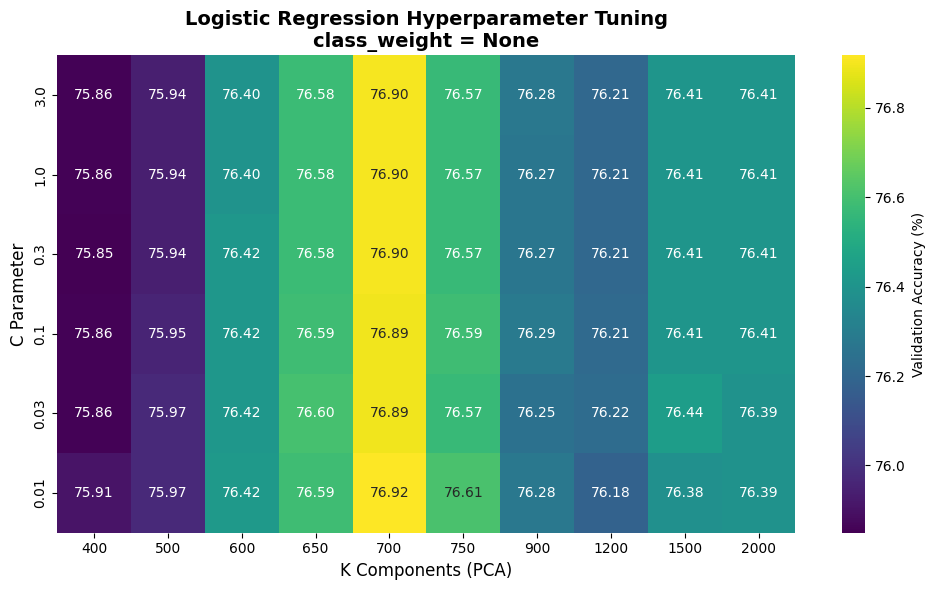

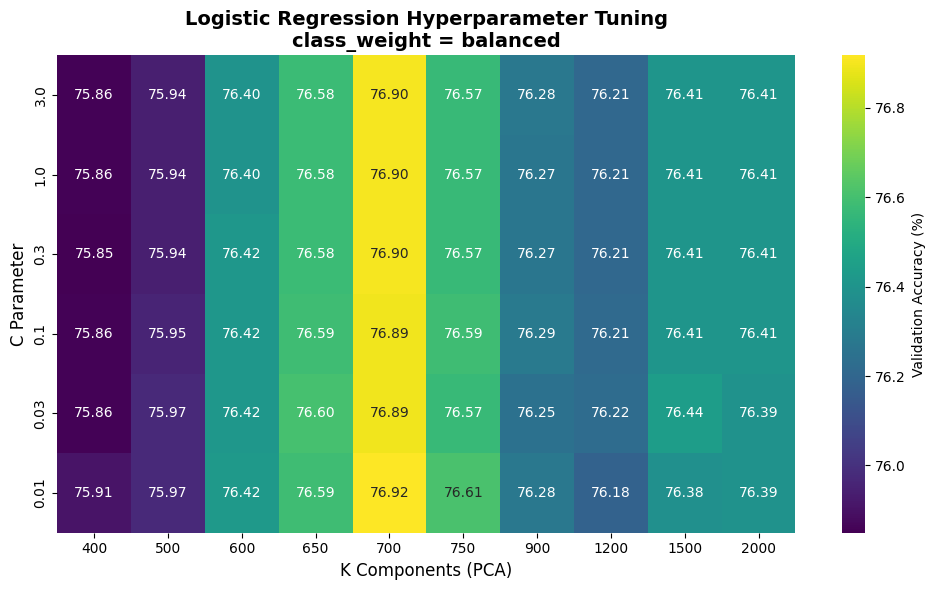

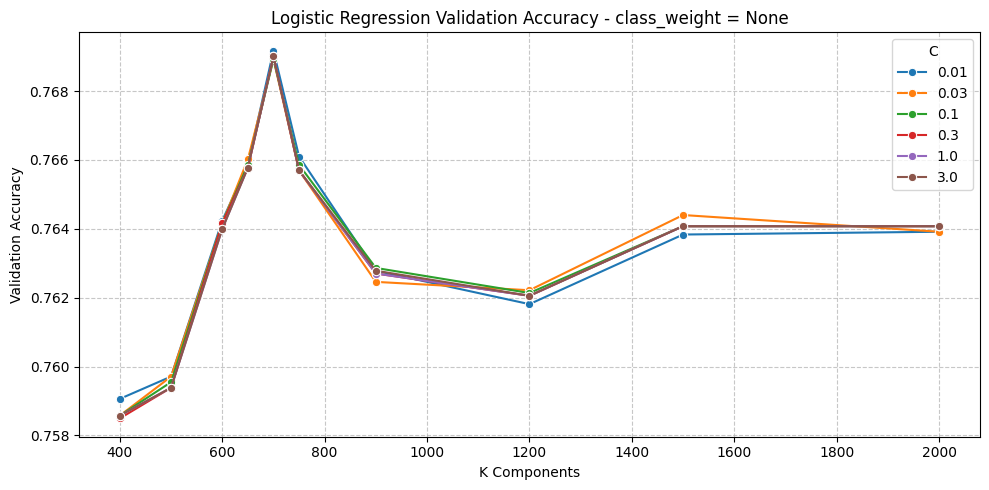

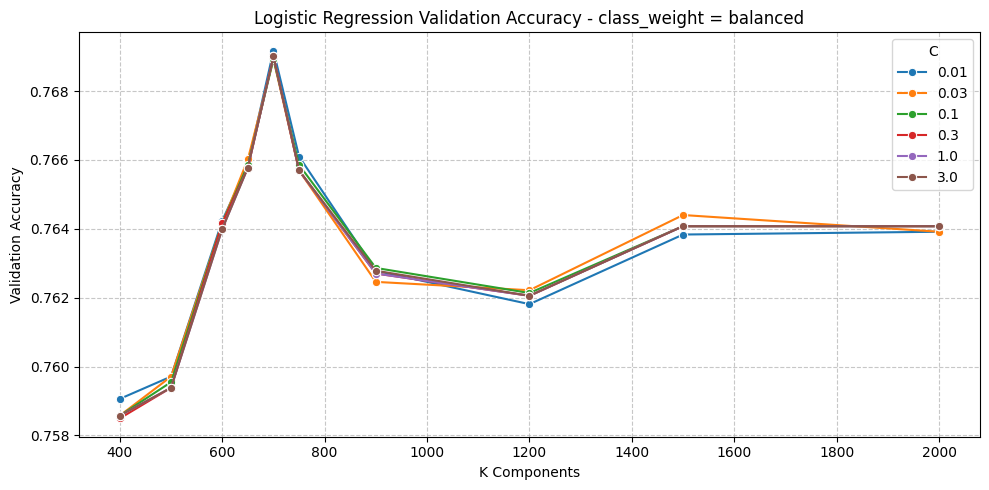

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_results = pd.DataFrame(results)

df_results.head()

for cw in df_results["class_weight"].unique():
    df_cw = df_results[df_results["class_weight"] == cw]

    heatmap_data = df_cw.pivot(
        index="C",
        columns="k_components",
        values="val_accuracy"
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        heatmap_data * 100,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        cbar_kws={"label": "Validation Accuracy (%)"}
    )

    plt.title(
        f"Logistic Regression Hyperparameter Tuning\nclass_weight = {cw}",
        fontsize=14,
        fontweight="bold"
    )
    plt.xlabel("K Components (PCA)", fontsize=12)
    plt.ylabel("C Parameter", fontsize=12)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

for cw in df_results["class_weight"].unique():
    df_cw = df_results[df_results["class_weight"] == cw]

    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=df_cw,
        x="k_components",
        y="val_accuracy",
        hue="C",
        marker="o",
        palette="tab10"
    )

    plt.title(f"Logistic Regression Validation Accuracy - class_weight = {cw}")
    plt.xlabel("K Components")
    plt.ylabel("Validation Accuracy")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend(title="C")
    plt.tight_layout()
    plt.show()

### 6.3.2 Train model on train + valid data

In [12]:
best_k = best_params["k_components"]
best_C = best_params["C"]
best_class_weight = best_params["class_weight"]

X_train = X_train_pca[:, :best_k]
X_valid = X_valid_pca[:, :best_k]
X_test = X_test_pca[:, :best_k]

X_train_full = np.vstack((X_train, X_valid))
y_train_full = np.concatenate((y_train, y_valid))

lr_pca_scaler = StandardScaler()
X_train_full_sc = lr_pca_scaler.fit_transform(X_train_full)
X_test_sc = lr_pca_scaler.transform(X_test)

final_lr = LogisticRegression(
    penalty='l2',
    C=best_C,
    solver='saga',
    max_iter=5000,
    tol=1e-3,
    class_weight=best_class_weight,
    random_state=42,
    n_jobs=-1
)

final_lr.fit(X_train_full_sc, y_train_full)

LogisticRegression(C=0.01, max_iter=5000, n_jobs=-1, random_state=42,
                   solver='saga', tol=0.001)

## 6.4 Evaluation 

Accuracy: 70.90%
F1 FAKE: 0.7521
ROC-AUC: 0.8079
              precision    recall  f1-score   support

    REAL (0)       0.82      0.54      0.65      2604
    FAKE (1)       0.66      0.88      0.75      2623

    accuracy                           0.71      5227
   macro avg       0.74      0.71      0.70      5227
weighted avg       0.74      0.71      0.70      5227



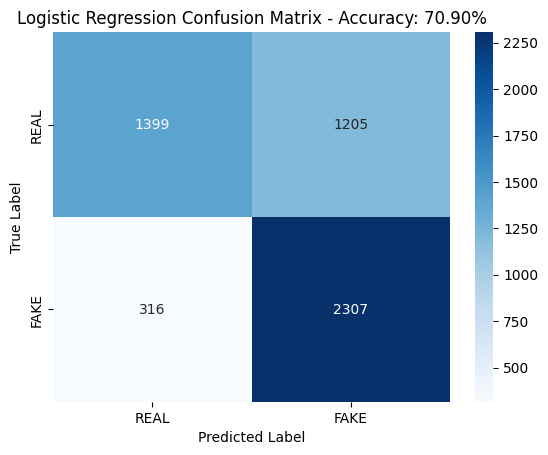

In [13]:
y_pred = final_lr.predict(X_test_sc)
y_prob = final_lr.predict_proba(X_test_sc)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc*100:.2f}%")
print(f"F1 FAKE: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print(classification_report(y_test, y_pred, target_names=["REAL (0)", "FAKE (1)"]))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['REAL', 'FAKE'],
    yticklabels=['REAL', 'FAKE']
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Logistic Regression Confusion Matrix - Accuracy: {acc*100:.2f}%")
plt.show()

## 6.5 Save model

In [14]:
import joblib
import os

SAVE_DIR = "/kaggle/working"

save_data = {
    "model_type": "LogisticRegression",
    "model": final_lr,
    "pca_output_scaler": lr_pca_scaler,
    "best_params": best_params,
    "test_accuracy": acc,
    "test_f1_fake": f1,
    "test_roc_auc": roc_auc,
    "classes": ["REAL", "FAKE"]
}

save_path = os.path.join(SAVE_DIR, "logistic_regression_model.pkl")

joblib.dump(save_data, save_path)

print(f"Model saved at: {save_path}")

Model saved at: /kaggle/working/logistic_regression_model.pkl


# DEMO

In [31]:
import joblib
import os

saved_config = {
    "k_components": best_k,
    "reg_param": best_reg,
    "img_size": CONFIG["IMG_SIZE"],
    "fft_low_radius": CONFIG["FFT_LOW_RADIUS"],
    "fft_mid_radius": CONFIG["FFT_MID_RADIUS"],
    "ela_quality": CONFIG["ELA_QUALITY"],
    "lbp_points": CONFIG["LBP_POINTS"],
    "lbp_radius": CONFIG["LBP_RADIUS"],
    "lbp_method": CONFIG["LBP_METHOD"]
}


pipeline_data = {
    "model_type": "GDA",
    "model": final_gda,   
    "scaler": scaler,      
    "pca": pca,           
    "config": saved_config
}

model_path = os.path.join(CONFIG["WORKING_DIR"], "model.pkl")
joblib.dump(pipeline_data, model_path)

print(f"Pipeline saved at: {model_path}")

Pipeline saved at: /kaggle/working/model.pkl


In [34]:
import gradio as gr

model_path = os.path.join(CONFIG["WORKING_DIR"], 'model.pkl')
pipeline = joblib.load(model_path)

gda_web = pipeline["model"]
scaler_web = pipeline["scaler"]
pca_web = pipeline["pca"]
app_config = pipeline["config"]
k_web = app_config["k_components"]

_init_worker(
    app_config["img_size"][0], app_config["img_size"][1],
    app_config["fft_low_radius"], app_config["fft_mid_radius"],
    app_config["ela_quality"],
    app_config["lbp_points"], app_config["lbp_radius"], app_config["lbp_method"]
)

def predict_forgery(upload_img):
    if upload_img is None:
        return {"Lỗi: Vui lòng tải ảnh lên": 1.0}
    
    img_bgr = cv2.cvtColor(upload_img, cv2.COLOR_RGB2BGR)
    
    temp_path = os.path.join(CONFIG["WORKING_DIR"], "temp_demo_img.jpg")
    cv2.imwrite(temp_path, img_bgr)
    
    try:
        features = extract_single_image_features(temp_path)
        if features is None:
            return {"Lỗi: Hình ảnh bị hỏng hoặc không đọc được": 1.0}
            
        features_2d = features.reshape(1, -1)
        feat_sc = scaler_web.transform(features_2d)
        feat_pca = pca_web.transform(feat_sc)
        feat_final = feat_pca[:, :k_web]

        probs = gda_web.predict_proba(feat_final)[0]
        prob_real = float(probs[0])
        prob_fake = float(probs[1])
        
        if os.path.exists(temp_path):
            os.remove(temp_path)

        return {"FAKE": prob_fake, "REAL": prob_real}
        
    except Exception as e:
        return {f"Lỗi hệ thống: {str(e)}": 1.0}


demo = gr.Interface(
    fn=predict_forgery, 
    inputs=gr.Image(type="numpy", label="Tải ảnh cần kiểm tra lên đây"), 
    outputs=gr.Label(num_top_classes=2, label="Forensics Result"),
    title="Image Forensics Detector",
    description="Nhận diện ảnh Fake/Real (GDA)",
    theme="default",
    allow_flagging="never"
)

# demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://02a995f17b8054a20f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error